# Определение возраста покупателей

__Описание проекта__

Сетевой супермаркет «Хлеб-Соль» внедряет систему компьютерного зрения для обработки фотографий покупателей. Фотофиксация в прикассовой зоне поможет определять возраст клиентов, чтобы:

- Анализировать покупки и предлагать товары, которые могут заинтересовать покупателей этой возрастной группы;
- Контролировать добросовестность кассиров при продаже алкоголя.

Постройте модель, которая по фотографии определит приблизительный возраст человека. В вашем распоряжении набор фотографий людей с указанием возраста.

__Общий вывод по задаче__

Цель проекта — достичь MAE < 8.0 при прогнозировании возраста по фото — успешно выполнена.
По результатам обучения, начиная с 3-й эпохи метрика на валидации стабильно ниже порогового значения, а наилучшее значение `val_mae` составило **6.2393** (8-я эпоха), что существенно превышает требование по точности.

Модель на базе ResNet50 с дообучением показала уверенное снижение ошибки как на обучающей, так и на валидационной выборке, что говорит о хорошем обобщающем свойстве при текущей конфигурации аугментаций и гиперпараметров. Небольшие колебания метрики на последних эпохах могут быть связаны с вариативностью батчей и сложностью отдельных примеров, однако явного переобучения не наблюдается.

__Итог:__ модель пригодна для применения, цель по точности достигнута с запасом, дальнейшие улучшения возможны за счёт балансировки редких возрастов и дополнительной настройки аугментаций.


In [6]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator

D:\Programs\Anaconda3\envs\practicum_base\lib\site-packages\numpy\_typing\_scalars.py:12: FutureWarning: In the future `np.bool` will be defined as the corresponding NumPy scalar.
  _BoolLike_co = Union[bool, np.bool]


AttributeError: module 'numpy' has no attribute 'bool'.
`np.bool` was a deprecated alias for the builtin `bool`. To avoid this error in existing code, use `bool` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.bool_` here.
The aliases was originally deprecated in NumPy 1.20; for more details and guidance see the original release note at:
    https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations

## Исследовательский анализ данных

In [2]:
labels = pd.read_csv('')
labels.shape

(7591, 2)

In [10]:
labels.head(2)

,file_name,real_age
0,000000.jpg,4
1,000001.jpg,18


In [ ]:
labels.describe()

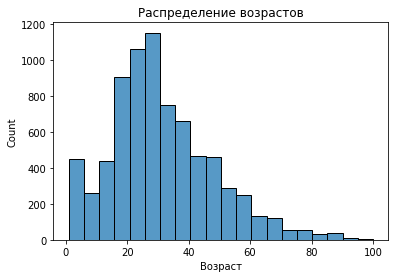

In [15]:
sns.histplot(labels['real_age'], bins=20)
plt.title('Распределение возрастов')
plt.xlabel('Возраст')
plt.ylabel('Количество')
plt.show()

In [ ]:
labels[(labels['real_age'] >= 20) & (labels['real_age'] <= 30)].shape[0] / labels.shape[0]

In [ ]:
labels[labels['real_age'] >= 60].shape[0] / labels.shape[0]

In [6]:
datagen = ImageDataGenerator(validation_split=.25, rescale=1./255)

In [14]:
datagen_flow = datagen.flow_from_dataframe(labels, '/datasets/faces/final_files',
                                           x_col='file_name', y_col='real_age',
                                           batch_size=15, class_mode='raw',
                                           subset='training', seed=12345)

Found 5694 validated image filenames.


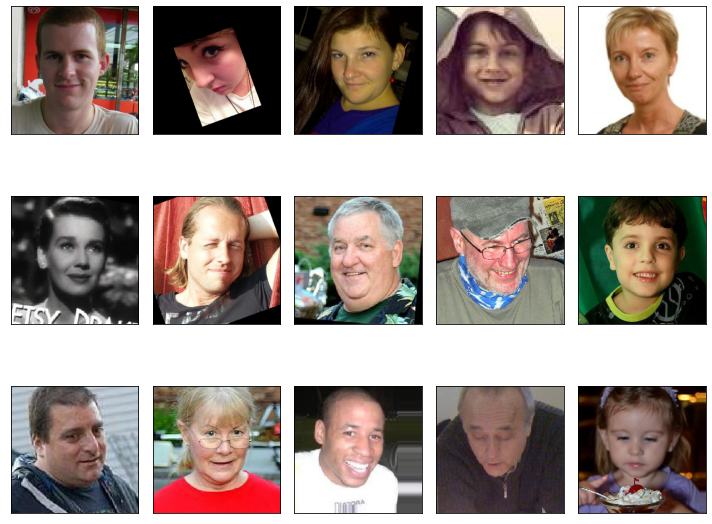

In [16]:
features, target = next(datagen_flow)

fig = plt.figure(figsize=(10, 10))
for i in range(15):
    fig.add_subplot(3, 5, i+1)
    plt.imshow(features[i])
    # для компактности удаляем оси и прижимаем изображения друг к другу
    plt.xticks([])
    plt.yticks([])
    plt.tight_layout()

- В датасете 7591 фото, возраст от 1 до 100 лет, медиана = 29 лет
- Наблюдается сильный дисбаланс - ~32% фото в диапазоне 20–30 лет, <7% старше 60 лет
- Для модели придётся использовать аугментацию для балансирования редких возрастов

## Код

Импортируем необходимые библиотеки

```
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet import ResNet50
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
import os
import pandas as pd
```

__Описание функции__

Функция `load_train(path)` загружает и подготавливает тренировочный набор изображений с аугментацией для задачи регрессии по меткам возраста.

__Входные данные__

`path (str)` — путь к директории, в которой находятся файл `labels.csv` с разметкой и папка `final_files` с изображениями.

__Выходные данные__

`train_datagen_flow` — генератор данных (`DirectoryIterator`), который возвращает батчи из изображений (нормализованных и аугментированных) и соответствующих численных меток возраста.

```
def load_train(path):
    datagen = ImageDataGenerator(
        rescale=1./255,
        width_shift_range=0.1,
        height_shift_range=0.1,
        zoom_range=0.2,
        horizontal_flip=True,
        validation_split=0.2,
    )

    df = pd.read_csv(path + 'labels.csv')

    train_datagen_flow = datagen.flow_from_dataframe(
        df,
        path + 'final_files',
        x_col='file_name',
        y_col='real_age',
        batch_size=16,
        class_mode='raw',
        subset='training',
        seed=12345
    )

    return train_datagen_flow
```

__Описание функции__

Функция `load_test(path)` загружает и подготавливает валидационный (тестовый) набор изображений без аугментации, только с нормализацией, для задачи регрессии по возрасту.

__Входные данные__

`path (str)` — путь к директории с файлом `labels.csv` и папкой `final_files`, содержащей изображения.

__Выходные данные__

`test_datagen_flow` — генератор данных (`DirectoryIterator`), который возвращает батчи нормализованных изображений и соответствующих численных меток возраста.

```
def load_test(path):
    datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)
    df = pd.read_csv(path + 'labels.csv')

    test_datagen_flow = datagen.flow_from_dataframe(
        df,
        path + 'final_files',
        x_col='file_name',
        y_col='real_age',
        batch_size=16,
        class_mode='raw',
        subset='validation',
        seed=12345
    )

    return test_datagen_flow

```

__Описание функции__

Функция `create_model(input_shape)` создаёт и компилирует сверточную нейросеть на базе предобученной архитектуры ResNet50 для задачи регрессии (прогноз возраста по изображению).

__Входные данные__

`input_shape (tuple)` — форма входного изображения в формате (высота, ширина, каналы), например (224, 224, 3).

__Выходные данные__

`model` — готовая к обучению модель Keras (Sequential).

```
def create_model(input_shape):
    base_model = ResNet50(include_top=False, weights='imagenet', input_shape=input_shape)

    base_model.trainable = True

    model = Sequential([
        base_model,
        GlobalAveragePooling2D(),
        Dropout(0.5),
        Dense(100, activation='relu'),
        Dropout(0.5),
        Dense(1, activation='linear')
    ])

    model.compile(
        optimizer=Adam(learning_rate=1e-4),
        loss='mean_squared_error',
        metrics=['mae']
    )

    return model
```

__Описание функции__

Функция `train_model(...)` обучает переданную модель на тренировочном наборе данных с валидацией, используя callbacks для динамического изменения скорости обучения и ранней остановки.

__Входные данные__
- `model` — модель Keras, подготовленная для обучения.
- `train_data` — генератор или набор данных для обучения.
- `test_data` — генератор или набор данных для валидации.
- `batch_size` (int, опционально) — размер батча.
- `epochs` (int) — количество эпох обучения (по умолчанию 10).
- `steps_per_epoch` (int, опционально) — число шагов на эпоху.
- `validation_steps` (int, опционально) — число шагов валидации за эпоху.

__Выходные данные__

Обученная модель `model`

```
def train_model(model, train_data, test_data, batch_size=None, epochs=10,
                steps_per_epoch=None, validation_steps=None):

    callbacks = [
        ReduceLROnPlateau(monitor='val_mae', factor=0.5, patience=3, verbose=1, mode='min', min_lr=1e-6),
        EarlyStopping(monitor='val_mae', patience=5, restore_best_weights=True, verbose=1, mode='min')
    ]

    model.fit(
        train_data,
        validation_data=test_data,
        batch_size=batch_size,
        epochs=epochs,
        callbacks=callbacks,
        steps_per_epoch=steps_per_epoch,
        validation_steps=validation_steps,
        verbose=2
    )

    return model
```

## Вывод модели

```
Train for 380 steps, validate for 95 steps

Epoch 1/10

2025-08-01 13:36:03.090248: I tensorflow/stream_executor/platform/default/dso_loader.cc:44] Successfully opened dynamic library libcublas.so.10

2025-08-01 13:36:03.670432: I tensorflow/stream_executor/platform/default/dso_loader.cc:44] Successfully opened dynamic library libcudnn.so.7

380/380 - 155s - loss: 250.4639 - mae: 11.7130 - val_loss: 459.4209 - val_mae: 16.2252

Epoch 2/10

380/380 - 120s - loss: 144.3727 - mae: 9.0982 - val_loss: 155.0477 - val_mae: 9.1855

Epoch 3/10

380/380 - 121s - loss: 122.2114 - mae: 8.3710 - val_loss: 96.1028 - val_mae: 7.6336

Epoch 4/10

380/380 - 126s - loss: 110.6780 - mae: 7.9824 - val_loss: 80.3426 - val_mae: 6.8158

Epoch 5/10

380/380 - 125s - loss: 102.4090 - mae: 7.7023 - val_loss: 76.7344 - val_mae: 6.4510

Epoch 6/10

380/380 - 121s - loss: 94.5506 - mae: 7.3492 - val_loss: 141.3453 - val_mae: 8.9170

Epoch 7/10

380/380 - 119s - loss: 92.9156 - mae: 7.2943 - val_loss: 113.4807 - val_mae: 7.6918

Epoch 8/10

380/380 - 119s - loss: 86.4578 - mae: 7.0464 - val_loss: 71.4174 - val_mae: 6.2393

Epoch 9/10

380/380 - 112s - loss: 77.6068 - mae: 6.7116 - val_loss: 136.5597 - val_mae: 9.2266

Epoch 10/10

380/380 - 112s - loss: 80.4739 - mae: 6.7717 - val_loss: 81.9398 - val_mae: 6.6875
```

## Выводы

Цель проекта — достичь MAE < 8.0 при прогнозировании возраста по фото — успешно выполнена.
По результатам обучения, начиная с 3-й эпохи метрика на валидации стабильно ниже порогового значения, а наилучшее значение `val_mae` составило **6.2393** (8-я эпоха), что существенно превышает требование по точности.

Модель на базе ResNet50 с дообучением показала уверенное снижение ошибки как на обучающей, так и на валидационной выборке, что говорит о хорошем обобщающем свойстве при текущей конфигурации аугментаций и гиперпараметров. Небольшие колебания метрики на последних эпохах могут быть связаны с вариативностью батчей и сложностью отдельных примеров, однако явного переобучения не наблюдается.

**Итог:** модель пригодна для применения, цель по точности достигнута с запасом, дальнейшие улучшения возможны за счёт балансировки редких возрастов и дополнительной настройки аугментаций.
